# Quickstart on mock data

This notebook runs the whole cellpy-core pipeline — `Data.from_raw_frame` →
`make_step_table` → `make_summary` — on synthetic data, so it works anywhere
the `cellpycore` package is installed (no cycler files needed).

The mock frame comes from `cellpycore.testing.mock_data.create_raw_data`,
which produces 1000 rows of charge / discharge / rest steps in the
[harmonized raw schema](../specifications/harmonized-raw.md).

In [1]:
import matplotlib.pyplot as plt

import cellpycore
from cellpycore import Data, make_step_table, make_summary
from cellpycore.testing.mock_data import create_raw_data

print(f"cellpycore version: {cellpycore.__version__}")

cellpycore version: 0.1.3


## 1. Create a raw frame

A raw frame is an ordinary polars `DataFrame` whose columns follow the
harmonized raw schema (`cellpycore.config.RawCols`).

In [2]:
raw = create_raw_data()
raw.select(
    "test_time", "cycle_num", "step_num", "step_type", "current", "potential"
).head()

test_time,cycle_num,step_num,step_type,current,potential
f64,i64,i64,str,f64,f64
0.0,0,0,"""charge""",1.0,3.7
1.0,0,0,"""charge""",1.1,3.71
2.0,0,0,"""charge""",1.2,3.72
3.0,0,0,"""discharge""",-1.3,3.67
4.0,0,0,"""discharge""",-1.4,3.66


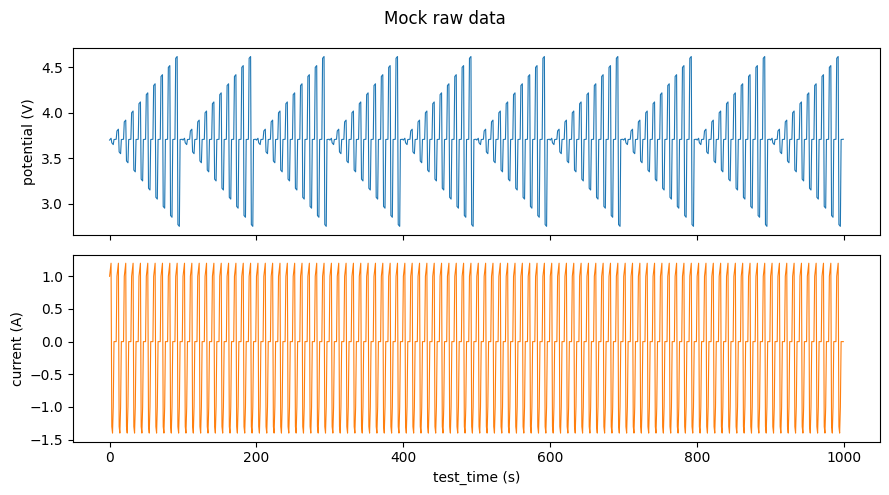

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(raw["test_time"], raw["potential"], lw=0.8)
ax1.set_ylabel("potential (V)")
ax2.plot(raw["test_time"], raw["current"], lw=0.8, color="tab:orange")
ax2.set_ylabel("current (A)")
ax2.set_xlabel("test_time (s)")
fig.suptitle("Mock raw data")
fig.tight_layout()

## 2. Run the pipeline

`Data.from_raw_frame` is the validating front door: it checks that the frame
carries the load-bearing columns with sane dtypes and reports every problem in
a single error. Then the step table must be built **before** the summary,
because `make_summary` reads `data.steps`.

In [4]:
data = Data.from_raw_frame(raw)
make_step_table(data)  # optional C-rate: add_step_c_rate(data, nom_cap_abs=...)
make_summary(data)

print(f"steps:   {data.steps.height} rows")
print(f"summary: {data.summary.height} cycles")

steps:   100 rows
summary: 10 cycles


## 3. Inspect the step table

One row per sequential step, with per-step statistics (first / last / min /
max / mean of current, potential, capacities …) and the classified
`step_type`.

In [5]:
data.steps.select(
    "cycle_num",
    "step_num",
    "step_type",
    "current_mean",
    "potential_first",
    "potential_last",
    "charge_capacity_last",
    "discharge_capacity_last",
).head(8)

cycle_num,step_num,step_type,current_mean,potential_first,potential_last,charge_capacity_last,discharge_capacity_last
i64,i64,str,f64,f64,f64,f64,f64
0,0,"""cv_discharge""",-0.04,3.7,3.709,0.33,0.37
0,1,"""discharge""",-0.04,3.8,3.709,0.66,0.74
0,2,"""discharge""",-0.04,3.9,3.709,0.99,1.11
0,3,"""discharge""",-0.04,4.0,3.709,1.32,1.48
0,4,"""discharge""",-0.04,4.1,3.709,1.65,1.85
0,5,"""discharge""",-0.04,4.2,3.709,1.98,2.22
0,6,"""discharge""",-0.04,4.3,3.709,2.31,2.59
0,7,"""discharge""",-0.04,4.4,3.709,2.64,2.96


## 4. Inspect the per-cycle summary

One row per cycle: capacities, coulombic efficiency, durations, and
per-direction current / potential statistics.

In [6]:
data.summary.select(
    "cycle_num",
    "charge_capacity",
    "discharge_capacity",
    "coulombic_efficiency",
    "last_test_time",
)

cycle_num,charge_capacity,discharge_capacity,coulombic_efficiency,last_test_time
i64,f64,f64,f64,f64
0,3.3,3.7,112.121212,99.0
1,6.6,7.4,112.121212,199.0
2,9.9,11.1,112.121212,299.0
3,13.2,14.8,112.121212,399.0
4,16.5,18.5,112.121212,499.0
5,19.8,22.2,112.121212,599.0
6,23.1,25.9,112.121212,699.0
7,26.4,29.6,112.121212,799.0
8,29.7,33.3,112.121212,899.0


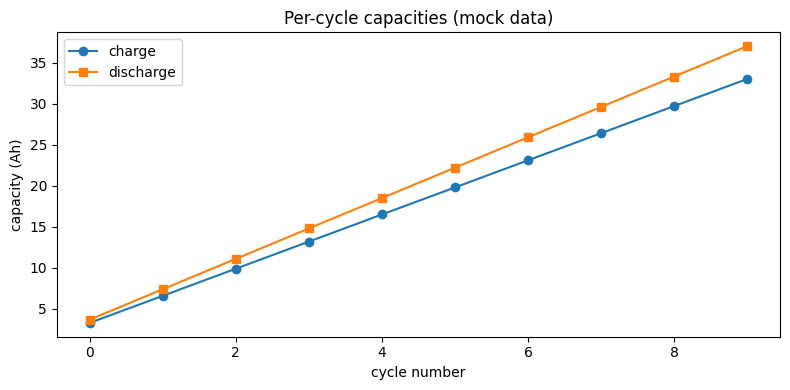

In [7]:
summary = data.summary
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(summary["cycle_num"], summary["charge_capacity"], "o-", label="charge")
ax.plot(summary["cycle_num"], summary["discharge_capacity"], "s-", label="discharge")
ax.set_xlabel("cycle number")
ax.set_ylabel("capacity (Ah)")
ax.set_title("Per-cycle capacities (mock data)")
ax.legend()
fig.tight_layout()

## Next steps

- The [real cycling data walkthrough](real_data_walkthrough.md) runs the same
  pipeline on genuine instrument data via the `CellpyCellCore` class, adding
  C-rates and half-cell cycle modes.
- The [standalone-use guide](../user-guide/standalone-use.md) documents the
  full contract the caller must honor.